# 0.Assignments

👾 這個陽春的聊天機器人需要被優化！<br>
若是一個對話串不間斷地持續進行，送進去的訊息量會很多，tokens數量也會跟著增加，會需要花比較多費用(💸💸💸)，也可能使模型的回應雜訊比較多而回應受到干擾，所以我們可以優化短期記憶。<br>
另外，我們希望優化使用者體驗，我們可以根據聊天的內容整理出使用者的屬性，並在每一次跟使用者聊天時，都能根據這個使用者的狀況給予客製化的回應，因此我們要加入長期記憶的功能！

<br>

### 1. 短期記憶優化

(1) 🔰 [基本版] 在短期記憶中，將chatbot node送入llm的訊息中加入trim的優化機制 (依據適當的tokens數量決定)


<br>

### 2. 加入長期記憶

加入長期記憶，讓聊天機器人能夠記住使用者的資訊（名字、偏好語言、興趣），在下一次對話也能針對同個使用者的資訊，給予個人化的回答。

(1) 🔰 [基本版]
- chatbot node: 在chatbot node中，將該使用者的資訊取出，讓入prompt中讓llm依據使用者的資訊給予個人化的回答

- write_memory node: 在每一次生成回答後，將使用者的資訊整理成一段對使用者的描述(使用llm，給予system prompt做指引，自行設計如何整理、需要整理哪些資訊)，將整理完的資訊整理到store (可跨threads存取的地方)。

- config: config從原本的短期記憶只有thread_id, 也要加入user_id

<img src="https://drive.google.com/uc?export=view&id=1H4Y0WplOi6R4Eo06Ac2JA_9TbZa2YaRD" width="100"/>


(2) 👨‍🎓 [進階版]
- chatbot node: 可以決定使用者的問題是否需要從長期記憶中取得資訊，以及需要取得什麼資訊
- write_memory node: 可以整理成特定格式 (例如：使用with_structured_output，相關概念可以延伸到R3 tool calling內容)。例如：
```
user_profile = {
  "first_name": "XXXX",
  "last_name": "OOO",
  "preferred_lang": ["en", "zh-tw"]
}
```
- 也可以自行將graph結構調整自己喜歡的(增刪不同node, conditional router, ...)
<br>
備註：基本版是需要大家完成的，進階版可以自行決定是否挑戰，Enjoy the ride! 😎

# 1.短期記憶

## (1) 基本版
🔰 [基本版] 在短期記憶中，將chatbot node送入llm的訊息中加入trim的優化機制 (依據適當的tokens數量決定)

note: 可以邊做邊看一下trim設定的效果以及內部運作的機制

In [ ]:
%%capture --no-stderr
!pip install -U langgraph langchain_openai==0.3.15 langchain transformers bitsandbytes langchain-huggingface


In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

load_dotenv()

True

In [2]:
# llm = init_chat_model("openai:gpt-4.1-mini")
llm = init_chat_model(
    "anthropic.claude-3-5-sonnet-20240620-v1:0",
    model_provider="bedrock_converse",
)

In [24]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, trim_messages
from langchain_core.messages.utils import count_tokens_approximately

from langgraph.checkpoint.memory import MemorySaver

class State(TypedDict):
  messages: Annotated[list, add_messages]

def chatbot(state: State):
  filterd_messages = trim_messages(
    state["messages"], 
    max_tokens=45,
    strategy="last", 
    token_counter=count_tokens_approximately,
    include_system=True,
    allow_partial=False,
  )
  return {"messages": [llm.invoke(filterd_messages)]}

# 建立graph
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot) # 在graph裡面加入chatbot的node
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# 加入短期記憶
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)


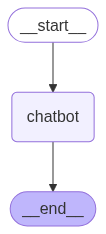

In [25]:
# 看一下graph
from IPython.display import Image, display

try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
  print(e)
  pass

In [26]:
def stream_graph_updates(user_input: str, config: dict):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}, config):
      if "chatbot" in event:
        for value in event.values():
          print("Assistant:", value["messages"][-1].content)

In [27]:
# 設定對話config (第一次對話)
config = {"configurable": {"thread_id": "conversation_1"}} # thread_id: 對話id

In [28]:
# 開始對話 (可以輸入quit, exit, q，三選一停止對話)
while True:
  try:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
      print("Goodbye!")
      break
    stream_graph_updates(user_input, config)
  except Exception as e:
    print(e)
    break

Assistant: 你好!很高兴和你交谈。今天我能为你做些什么呢?有什么我可以帮助你的吗?
Assistant: 你好 Benson! 很高兴认识你。希望你今天过得愉快。有什么特别的话题你想聊聊吗？或者有什么我可以帮助你的吗？
Assistant: 你刚刚告诉我你叫 Benson。这是一个很好的名字!

如果你是在确认我是否记得你的名字，那么是的，我记得。如果你是想告诉我你有另一个名字，或者Benson只是一个昵称，那么请随时告诉我你希望我怎么称呼你。

你希望我叫你Benson还是有其他你更喜欢的称呼?
Assistant: 对不起,看来我之前理解错误了。我没有之前的对话记录,所以不知道你的名字是Benson。我是一个AI助手,每次对话都是独立的,不会记住之前的交谈内容。

既然你说"okay",那我们就重新开始吧。你有什么想聊的话题或需要帮助的地方吗?我很乐意为你提供帮助。
Goodbye!


---

# 2.長期記憶

## (1) 基本版
🔰 [基本版]
- chatbot node: 在chatbot node中，將該使用者的資訊取出，讓入prompt中讓llm依據使用者的資訊給予個人化的回答

- write_memory node: 在每一次生成回答後，將使用者的資訊整理成一段對使用者的描述(使用llm，給予system prompt做指引，自行設計如何整理、需要整理哪些資訊)，將整理完的資訊整理到store (可跨threads存取的地方)。

- config: config從原本的短期記憶只有thread_id, 也要加入user_id

<img src="https://drive.google.com/uc?export=view&id=1H4Y0WplOi6R4Eo06Ac2JA_9TbZa2YaRD" width="100"/>

In [ ]:
%%capture --no-stderr
!pip install langchain_core

In [3]:
# 💻code here, enjoy the ride 😎
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig

# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """你是一個有記憶功能的助手，可以提供關於用戶的資訊。
如果你有這個用戶的記憶，請用它來個人化你的回應。
以下是記憶內容（可能為空）：{memory}"""

# Create new memory from the chat history and any existing memory
CREATE_MEMORY_INSTRUCTION = """你正在收集用戶資訊以個人化你的回應。

目前用戶資訊：
{memory}

指示：
1. 仔細檢視以下對話歷史
2. 識別關於用戶的新資訊，例如：
   - 個人資料（姓名、地點）
   - 偏好（喜歡、不喜歡）
   - 興趣和嗜好
   - 過去經驗
   - 目標或未來計劃
3. 將新資訊與現有記憶合併
4. 將記憶格式化為清晰的項目列表
5. 如果新資訊與現有記憶衝突，保留最新版本

請記住：只包含用戶直接陳述的事實資訊。不要做出假設或推論。

根據以下對話歷史，請更新用戶資訊："""

In [4]:
def call_model(state: MessagesState,
              config: RunnableConfig,
              store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)
    
    if existing_memory:
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."
        
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=existing_memory_content)
    response = llm.invoke([SystemMessage(content=system_msg)] + state["messages"])
    
    return {"messages": response}
    
def write_memory(state: MessagesState,
              config: RunnableConfig,
              store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)

    if existing_memory:
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."
        
    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=existing_memory_content)
    new_memory = llm.invoke([SystemMessage(content=system_msg)] + state['messages'])
    
    store.put(namespace, key, {"memory": new_memory.content})

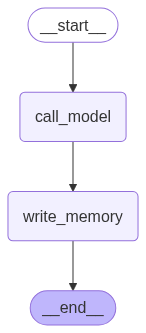

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

across_thread_memory = InMemoryStore()
within_thread_memory = MemorySaver()
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [6]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="Hi,我是 benson")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi,我是 benson
================================== Ai Message ==================================

你好 Benson! 很高興認識你。我是一個AI助手,可以回答問題、提供建議和進行對話。請問有什麼我可以幫到你的嗎?你有任何特別感興趣的話題或需要協助的事情嗎?我很樂意聽你分享,也可以針對你的需求提供更個人化的服務。


In [7]:
config = {"configurable": {"thread_id": "2", "user_id": "2"}}

# User input 
input_messages = [HumanMessage(content="Hi,我是 kevin")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi,我是 kevin
================================== Ai Message ==================================

你好 Kevin!很高興認識你。我是一個 AI 助手,很樂意為你提供幫助。由於這是我們第一次交流,我對你還不太了解。不過我會記住你叫 Kevin,以後會用這個名字稱呼你。你有什麼我可以幫忙的嗎?或者你想聊些什麼話題?


In [8]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="我叫什麼")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我叫什麼
================================== Ai Message ==================================

你剛剛告訴我你叫 Benson。很高興認識你,Benson!


In [9]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "2", "user_id": "2"}}

# User input 
input_messages = [HumanMessage(content="我叫什麼")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

我叫什麼
================================== Ai Message ==================================

你告訴我你叫 Kevin。很高興再次確認你的名字!我會記住這個信息,以便在未來的對話中更好地為你服務。如果你有任何其他問題或者想聊些什麼,請隨時告訴我。


## (2) 進階版

👨‍🎓 [進階版]
- chatbot node: 可以決定使用者的問題是否需要從長期記憶中取得資訊，以及需要取得什麼資訊
- write_memory node: 可以整理成特定格式 (例如：使用with_structured_output，相關概念可以延伸到R3 tool calling內容)。例如：
```
user_profile = {
  "first_name": "XXXX",
  "last_name": "OOO",
  "preferred_lang": ["en", "zh-tw"]
}
```
- 也可以自行將graph結構調整自己喜歡的(增刪不同node, conditional router, ...)

In [ ]:
# 💻code here, enjoy the ride 😎

In [ ]:
from IPython.display import Image, display
from typing import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain.chat_models import init_chat_model

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig

In [14]:
class UserProfile(TypedDict):
    """User profile information"""
    user_name: str # user's name
    interests: list[str] # a list of user's interests
    
llm = init_chat_model("openai:gpt-4.1-mini")
llm_with_structured_output = llm.with_structured_output(UserProfile)
structured_output = llm_with_structured_output.invoke([HumanMessage(content="我叫 Benson，我喜歡吉他和看劇")])
structured_output

{'user_name': 'Benson', 'interests': ['吉他', '看劇']}

In [15]:
MODEL_SYSTEM_MESSAGE = """你是一個有記憶功能的助手，可以提供關於用戶的資訊。
如果你有這個用戶的記憶，請使用它來個人化你的回應。
這是記憶內容(可能為空): {memory}"""

CREATE_MEMORY_INSTRUCTION = """根據用戶的聊天歷史創建或更新用戶檔案記憶。
這將被保存為長期記憶。如果有現有的記憶，只需更新它。
這是現有的記憶(可能為空): {memory}"""

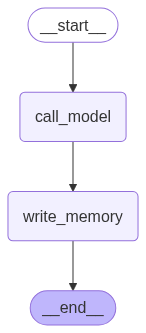

In [17]:
def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]

    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")

    if existing_memory and existing_memory.value:
        memory_dict = existing_memory.value
        formatted_memory = (
            f"姓名: {memory_dict.get('user_name', '未知')}\n"
            f"興趣: {', '.join(memory_dict.get('interests', []))}"
        )
    else:
        formatted_memory = None

    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=formatted_memory)

    response = llm.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]

    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")

    if existing_memory and existing_memory.value:
        memory_dict = existing_memory.value
        formatted_memory = (
            f"user_name: {memory_dict.get('user_name', '未知')}\n"
            f"interests: {', '.join(memory_dict.get('interests', []))}"
        )
    else:
        formatted_memory = None
        
    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=formatted_memory)

    new_memory = llm_with_structured_output.invoke([SystemMessage(content=system_msg)]+state['messages'])

    key = "user_memory"
    store.put(namespace, key, new_memory)

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

across_thread_memory = InMemoryStore()

within_thread_memory = MemorySaver()

graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [18]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="HI 我是 Benson，我的興趣是彈吉他跟看劇")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

HI 我是 Benson，我的興趣是彈吉他跟看劇
================================== Ai Message ==================================

嗨 Benson！很高興認識你！你喜歡彈吉他和看劇，真棒！你有最喜歡的吉他曲或者劇集嗎？還是你喜歡哪種類型的音樂和劇情？我很樂意跟你聊聊喔！


In [19]:
# Namespace for the memory to save
user_id = "1"
namespace = ("memory", user_id)
existing_memory = across_thread_memory.get(namespace, "user_memory")
existing_memory.value

{'user_name': 'Benson', 'interests': ['彈吉他', '看劇']}